<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter3/3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K 최근접 이웃 알고리즘 회귀

지도 학습의 한 종류인 회귀 문제를 이해하고 알고리즘을 사용해 농어의 무게를 예측하는 회귀.

지도학습의 알고리즘은 분류와 회귀로 나뉨. 분류는 앞 챕터처럼 샘플을 몇개의 클래스 중 하나로 분류.
회귀는 클래스 중 하나로 분류하는 것이 아니라 임의의 어떤 숫자를 예측하는 것.

In [11]:
import numpy as np

In [12]:
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

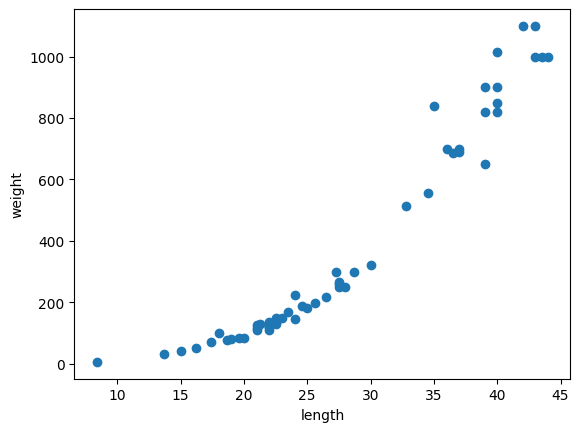

In [13]:
#그래프
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [14]:
#데이터 분류
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

2차원 배열로 만들어줘야하는데 앞 챕터에서는 2개의 특성을 사용해서 자연스럽게 열이 2개. 하지만 여기서는 열이 1개이므로 다시 만들어줘야함. 그때 필요한 메서드가 reshape().

In [15]:
#reshape((-1, 1)은 열을 1로 맞추고 여기에 행을 맞추기 위한 편리한 기능)
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


# 결정계수 $R^2$

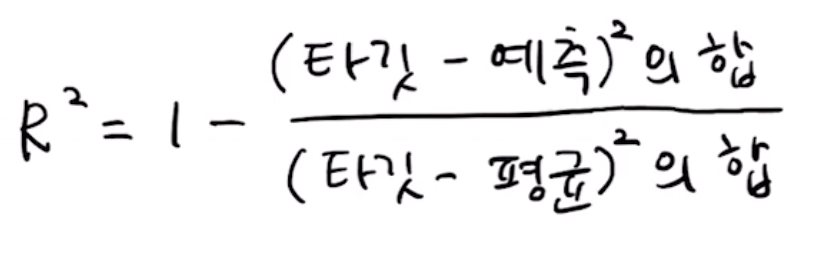

In [16]:
#회귀 모델 훈련(이 점수가 결정계수 R^2)
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor()
knr.fit(train_input, train_target)
knr.score(test_input, test_target)

0.992809406101064

예측한 값이 평균값과 비슷하면 결정계수의 오른쪽 값이 0에 가까워지니 결정계수는 1에 가까워진다.

In [17]:
#mean_absolute_error는 타깃과 예측의 절댓값 오차를 평균하여 반환한다. 타깃과 예측한 값 사이의 차이를 구해보면 어느정도 예측이 벗어났는지 가늠하기 좋음
#결과에서 예측이 평균적으로 19g 타깃값과 다르다는 것을 알 수 있음.

from sklearn.metrics import mean_absolute_error

test_prediction = knr.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


# 과대적합과 과소적합

In [18]:
#훈련모델을 사용해 결정계수 계산
print(knr.score(train_input, train_target))

0.9698823289099254


훈련세트의 점수가 테스트세트의 점수보다 낮다. 이럴때는 모델이 훈련 세트에 과소적합 되었다고 말한다. 모델이 너무 단순하여 훈련 세트에 적절히 훈련되지 않은 경우.

반대로 훈련세트가 테스트세트보다 높으면 과대적합. 훈련세트에만 잘맞는 모델이라 테스트 세트와 나중에 실전에 투입되어 새로운 샘플에 대한 예측을 만들 때 잘 동작할지 않을 것이다.

왜 과소적합이 일어나는가? 하나의 원인은 훈련 세트와 테스트 세트의 크기가 매우 작기 때문.

In [19]:
#과소적합 해결 -> 모델을 복잡하게 만들기. 즉 훈련세트에 더 잘 맞게 만들기. -> 이웃의 개수 k 줄이기
knr.n_neighbors = 3
knr.fit(train_input, train_target)

print(knr.score(train_input, train_target))

print(knr.score(test_input, test_target))

0.9804899950518966
0.9746459963987609
